In [19]:
# loading datasets
import pandas as pd

df = pd.read_csv("/content/ADANIPORTS.csv")
print(df.head())
print(df.info())
print(df.describe())

         Date      Symbol Series  Prev Close    Open     High    Low   Last  \
0  2007-11-27  MUNDRAPORT     EQ      440.00  770.00  1050.00  770.0  959.0   
1  2007-11-28  MUNDRAPORT     EQ      962.90  984.00   990.00  874.0  885.0   
2  2007-11-29  MUNDRAPORT     EQ      893.90  909.00   914.75  841.0  887.0   
3  2007-11-30  MUNDRAPORT     EQ      884.20  890.00   958.00  890.0  929.0   
4  2007-12-03  MUNDRAPORT     EQ      921.55  939.75   995.00  922.0  980.0   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  962.90  984.72  27294366  2.687719e+15     NaN             9859619   
1  893.90  941.38   4581338  4.312765e+14     NaN             1453278   
2  884.20  888.09   5124121  4.550658e+14     NaN             1069678   
3  921.55  929.17   4609762  4.283257e+14     NaN             1260913   
4  969.30  965.65   2977470  2.875200e+14     NaN              816123   

   %Deliverble  
0       0.3612  
1       0.3172  
2       0.2088  
3       0.2735  
4

In [20]:
# Data preprocessing
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Symbol', 'Date']).reset_index(drop=True)

In [21]:
# Handling missing values by forward filling
df[['Open','High','Low','Close']] = df.groupby('Symbol')[['Open','High','Low','Close']].ffill()
print(df)


           Date      Symbol Series  Prev Close    Open    High     Low  \
0    2012-01-17  ADANIPORTS     EQ      135.50  137.10  141.00  135.00   
1    2012-01-18  ADANIPORTS     EQ      140.00  142.00  143.80  138.70   
2    2012-01-19  ADANIPORTS     EQ      141.70  144.00  150.55  143.15   
3    2012-01-20  ADANIPORTS     EQ      149.40  151.90  157.60  150.25   
4    2012-01-23  ADANIPORTS     EQ      155.40  155.40  155.40  145.10   
...         ...         ...    ...         ...     ...     ...     ...   
3317 2012-01-10  MUNDRAPORT     EQ      132.20  133.85  137.00  132.85   
3318 2012-01-11  MUNDRAPORT     EQ      136.45  136.00  140.70  134.75   
3319 2012-01-12  MUNDRAPORT     EQ      137.05  137.50  137.50  131.20   
3320 2012-01-13  MUNDRAPORT     EQ      132.65  132.50  133.00  129.55   
3321 2012-01-16  MUNDRAPORT     EQ      131.55  131.50  136.40  130.65   

        Last   Close    VWAP   Volume      Turnover   Trades  \
0     140.10  140.00  138.13  1636196  2.260074

In [22]:
# Removing duplicate entries based on 'Date' and 'Symbol'
df = df.drop_duplicates(subset=['Date', 'Symbol'])
print(df)

           Date      Symbol Series  Prev Close    Open    High     Low  \
0    2012-01-17  ADANIPORTS     EQ      135.50  137.10  141.00  135.00   
1    2012-01-18  ADANIPORTS     EQ      140.00  142.00  143.80  138.70   
2    2012-01-19  ADANIPORTS     EQ      141.70  144.00  150.55  143.15   
3    2012-01-20  ADANIPORTS     EQ      149.40  151.90  157.60  150.25   
4    2012-01-23  ADANIPORTS     EQ      155.40  155.40  155.40  145.10   
...         ...         ...    ...         ...     ...     ...     ...   
3317 2012-01-10  MUNDRAPORT     EQ      132.20  133.85  137.00  132.85   
3318 2012-01-11  MUNDRAPORT     EQ      136.45  136.00  140.70  134.75   
3319 2012-01-12  MUNDRAPORT     EQ      137.05  137.50  137.50  131.20   
3320 2012-01-13  MUNDRAPORT     EQ      132.65  132.50  133.00  129.55   
3321 2012-01-16  MUNDRAPORT     EQ      131.55  131.50  136.40  130.65   

        Last   Close    VWAP   Volume      Turnover   Trades  \
0     140.10  140.00  138.13  1636196  2.260074

In [23]:
# Removing rows with non-positive 'Open' or 'Close' prices
df = df[(df['Open'] > 0) & (df['Close'] > 0)]

from scipy import stats
df = df[(abs(stats.zscore(df['Close'])) < 3)]
print(df)

           Date      Symbol Series  Prev Close    Open    High     Low  \
0    2012-01-17  ADANIPORTS     EQ      135.50  137.10  141.00  135.00   
1    2012-01-18  ADANIPORTS     EQ      140.00  142.00  143.80  138.70   
2    2012-01-19  ADANIPORTS     EQ      141.70  144.00  150.55  143.15   
3    2012-01-20  ADANIPORTS     EQ      149.40  151.90  157.60  150.25   
4    2012-01-23  ADANIPORTS     EQ      155.40  155.40  155.40  145.10   
...         ...         ...    ...         ...     ...     ...     ...   
3317 2012-01-10  MUNDRAPORT     EQ      132.20  133.85  137.00  132.85   
3318 2012-01-11  MUNDRAPORT     EQ      136.45  136.00  140.70  134.75   
3319 2012-01-12  MUNDRAPORT     EQ      137.05  137.50  137.50  131.20   
3320 2012-01-13  MUNDRAPORT     EQ      132.65  132.50  133.00  129.55   
3321 2012-01-16  MUNDRAPORT     EQ      131.55  131.50  136.40  130.65   

        Last   Close    VWAP   Volume      Turnover   Trades  \
0     140.10  140.00  138.13  1636196  2.260074

In [24]:
# Saving the cleaned dataset
df.to_csv("cleaned_equities.csv", index=False)

In [25]:
# Loading cleaned dataset
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned_equities.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Symbol', 'Date']).reset_index(drop=True)


In [26]:
# 20-day and 50-day Moving Averages
df['SMA_20'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(window=20).mean())
df['EMA_20'] = df.groupby('Symbol')['Close'].transform(lambda x: x.ewm(span=20, adjust=False).mean())
print(df)

           Date      Symbol Series  Prev Close    Open    High     Low  \
0    2012-01-17  ADANIPORTS     EQ      135.50  137.10  141.00  135.00   
1    2012-01-18  ADANIPORTS     EQ      140.00  142.00  143.80  138.70   
2    2012-01-19  ADANIPORTS     EQ      141.70  144.00  150.55  143.15   
3    2012-01-20  ADANIPORTS     EQ      149.40  151.90  157.60  150.25   
4    2012-01-23  ADANIPORTS     EQ      155.40  155.40  155.40  145.10   
...         ...         ...    ...         ...     ...     ...     ...   
3283 2012-01-10  MUNDRAPORT     EQ      132.20  133.85  137.00  132.85   
3284 2012-01-11  MUNDRAPORT     EQ      136.45  136.00  140.70  134.75   
3285 2012-01-12  MUNDRAPORT     EQ      137.05  137.50  137.50  131.20   
3286 2012-01-13  MUNDRAPORT     EQ      132.65  132.50  133.00  129.55   
3287 2012-01-16  MUNDRAPORT     EQ      131.55  131.50  136.40  130.65   

        Last   Close    VWAP   Volume      Turnover   Trades  \
0     140.10  140.00  138.13  1636196  2.260074

In [27]:
# Relative Strength Index (RSI)
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI_14'] = df.groupby('Symbol')['Close'].transform(lambda x: compute_rsi(x))
print(df)

           Date      Symbol Series  Prev Close    Open    High     Low  \
0    2012-01-17  ADANIPORTS     EQ      135.50  137.10  141.00  135.00   
1    2012-01-18  ADANIPORTS     EQ      140.00  142.00  143.80  138.70   
2    2012-01-19  ADANIPORTS     EQ      141.70  144.00  150.55  143.15   
3    2012-01-20  ADANIPORTS     EQ      149.40  151.90  157.60  150.25   
4    2012-01-23  ADANIPORTS     EQ      155.40  155.40  155.40  145.10   
...         ...         ...    ...         ...     ...     ...     ...   
3283 2012-01-10  MUNDRAPORT     EQ      132.20  133.85  137.00  132.85   
3284 2012-01-11  MUNDRAPORT     EQ      136.45  136.00  140.70  134.75   
3285 2012-01-12  MUNDRAPORT     EQ      137.05  137.50  137.50  131.20   
3286 2012-01-13  MUNDRAPORT     EQ      132.65  132.50  133.00  129.55   
3287 2012-01-16  MUNDRAPORT     EQ      131.55  131.50  136.40  130.65   

        Last   Close    VWAP   Volume      Turnover   Trades  \
0     140.10  140.00  138.13  1636196  2.260074

In [28]:
# Bollinger Bands
rolling_mean = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(window=20).mean())
rolling_std = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(window=20).std())

df['Bollinger_Upper'] = rolling_mean + (rolling_std * 2)
df['Bollinger_Lower'] = rolling_mean - (rolling_std * 2)
print(df)

           Date      Symbol Series  Prev Close    Open    High     Low  \
0    2012-01-17  ADANIPORTS     EQ      135.50  137.10  141.00  135.00   
1    2012-01-18  ADANIPORTS     EQ      140.00  142.00  143.80  138.70   
2    2012-01-19  ADANIPORTS     EQ      141.70  144.00  150.55  143.15   
3    2012-01-20  ADANIPORTS     EQ      149.40  151.90  157.60  150.25   
4    2012-01-23  ADANIPORTS     EQ      155.40  155.40  155.40  145.10   
...         ...         ...    ...         ...     ...     ...     ...   
3283 2012-01-10  MUNDRAPORT     EQ      132.20  133.85  137.00  132.85   
3284 2012-01-11  MUNDRAPORT     EQ      136.45  136.00  140.70  134.75   
3285 2012-01-12  MUNDRAPORT     EQ      137.05  137.50  137.50  131.20   
3286 2012-01-13  MUNDRAPORT     EQ      132.65  132.50  133.00  129.55   
3287 2012-01-16  MUNDRAPORT     EQ      131.55  131.50  136.40  130.65   

        Last   Close    VWAP   Volume      Turnover   Trades  \
0     140.10  140.00  138.13  1636196  2.260074

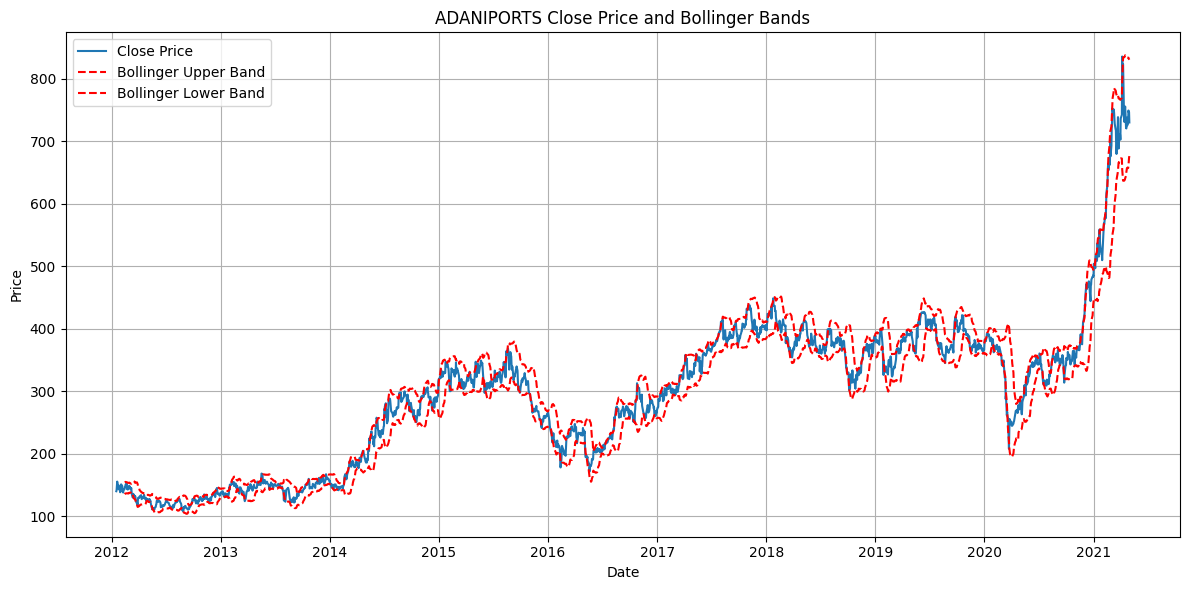

In [29]:
# Visualization of Bollinger Bands for a selected symbol
import matplotlib.pyplot as plt

# Choose a symbol to visualize
symbol_to_plot = 'ADANIPORTS'

# Filter the DataFrame for the selected symbol
df_plot = df[df['Symbol'] == symbol_to_plot].copy()

# Create a figure and axes
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the Close price and Bollinger Bands
ax.plot(df_plot['Date'], df_plot['Close'], label='Close Price')
ax.plot(df_plot['Date'], df_plot['Bollinger_Upper'], label='Bollinger Upper Band', color='red', linestyle='--')
ax.plot(df_plot['Date'], df_plot['Bollinger_Lower'], label='Bollinger Lower Band', color='red', linestyle='--')

ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.set_title(f'{symbol_to_plot} Close Price and Bollinger Bands')
ax.legend()
ax.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

In [30]:
# Volatility (Standard Deviation of Returns)
df['Return'] = df.groupby('Symbol')['Close'].pct_change()
df['Lag1_Return'] = df.groupby('Symbol')['Return'].shift(1)
df['Volatility_10'] = df.groupby('Symbol')['Return'].transform(lambda x: x.rolling(window=10).std())
print(df)

           Date      Symbol Series  Prev Close    Open    High     Low  \
0    2012-01-17  ADANIPORTS     EQ      135.50  137.10  141.00  135.00   
1    2012-01-18  ADANIPORTS     EQ      140.00  142.00  143.80  138.70   
2    2012-01-19  ADANIPORTS     EQ      141.70  144.00  150.55  143.15   
3    2012-01-20  ADANIPORTS     EQ      149.40  151.90  157.60  150.25   
4    2012-01-23  ADANIPORTS     EQ      155.40  155.40  155.40  145.10   
...         ...         ...    ...         ...     ...     ...     ...   
3283 2012-01-10  MUNDRAPORT     EQ      132.20  133.85  137.00  132.85   
3284 2012-01-11  MUNDRAPORT     EQ      136.45  136.00  140.70  134.75   
3285 2012-01-12  MUNDRAPORT     EQ      137.05  137.50  137.50  131.20   
3286 2012-01-13  MUNDRAPORT     EQ      132.65  132.50  133.00  129.55   
3287 2012-01-16  MUNDRAPORT     EQ      131.55  131.50  136.40  130.65   

        Last   Close    VWAP  ...  Deliverable Volume  %Deliverble    SMA_20  \
0     140.10  140.00  138.13  .

In [31]:
# Moving Average Convergence Divergence (MACD)
def compute_macd(series, short=12, long=26, signal=9):
    ema_short = series.ewm(span=short, adjust=False).mean()
    ema_long = series.ewm(span=long, adjust=False).mean()
    macd = ema_short - ema_long
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line

macd = []
signal_line = []

for _, group in df.groupby('Symbol')['Close']:
    m, s = compute_macd(group)
    macd.extend(m)
    signal_line.extend(s)

df['MACD'] = macd
df['MACD_signal'] = signal_line

print(df)

           Date      Symbol Series  Prev Close    Open    High     Low  \
0    2012-01-17  ADANIPORTS     EQ      135.50  137.10  141.00  135.00   
1    2012-01-18  ADANIPORTS     EQ      140.00  142.00  143.80  138.70   
2    2012-01-19  ADANIPORTS     EQ      141.70  144.00  150.55  143.15   
3    2012-01-20  ADANIPORTS     EQ      149.40  151.90  157.60  150.25   
4    2012-01-23  ADANIPORTS     EQ      155.40  155.40  155.40  145.10   
...         ...         ...    ...         ...     ...     ...     ...   
3283 2012-01-10  MUNDRAPORT     EQ      132.20  133.85  137.00  132.85   
3284 2012-01-11  MUNDRAPORT     EQ      136.45  136.00  140.70  134.75   
3285 2012-01-12  MUNDRAPORT     EQ      137.05  137.50  137.50  131.20   
3286 2012-01-13  MUNDRAPORT     EQ      132.65  132.50  133.00  129.55   
3287 2012-01-16  MUNDRAPORT     EQ      131.55  131.50  136.40  130.65   

        Last   Close    VWAP  ...    SMA_20      EMA_20     RSI_14  \
0     140.10  140.00  138.13  ...       N

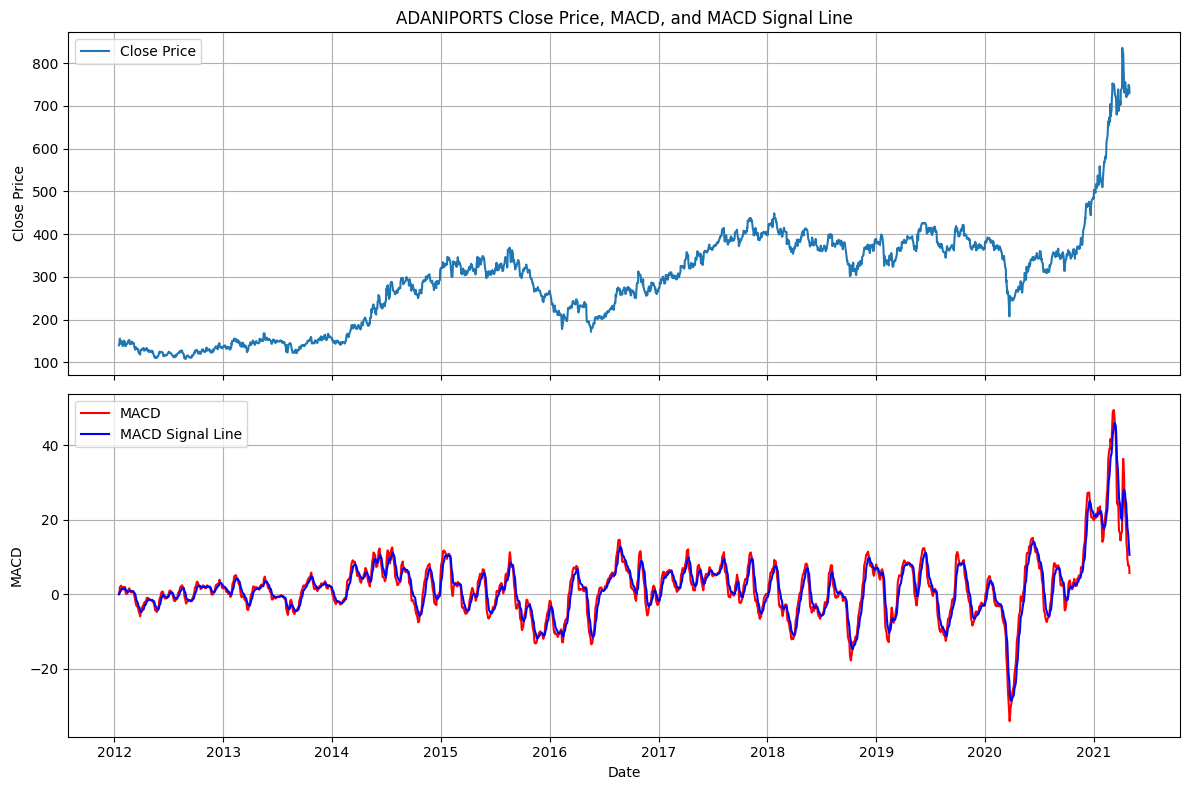

In [32]:
# Visualization of MACD for a selected symbol
import matplotlib.pyplot as plt

# Choose a symbol to visualize
symbol_to_plot = 'ADANIPORTS'  # You can change this to 'MUNDRAPORT'

# Filter the DataFrame for the selected symbol
df_plot = df[df['Symbol'] == symbol_to_plot].copy()

# Create a figure and a set of subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot the Close price on the first subplot
ax1.plot(df_plot['Date'], df_plot['Close'], label='Close Price')
ax1.set_ylabel('Close Price')
ax1.set_title(f'{symbol_to_plot} Close Price, MACD, and MACD Signal Line')
ax1.legend()
ax1.grid(True)

# Plot the MACD and MACD Signal Line on the second subplot
ax2.plot(df_plot['Date'], df_plot['MACD'], label='MACD', color='red')
ax2.plot(df_plot['Date'], df_plot['MACD_signal'], label='MACD Signal Line', color='blue')
ax2.set_ylabel('MACD')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

In [33]:
# Final cleaned dataset with features
df = df.dropna().reset_index(drop=True)
df.to_csv("equities_with_features.csv", index=False)
print(df)

           Date      Symbol Series  Prev Close    Open    High     Low  \
0    2012-02-14  ADANIPORTS     EQ      143.05  143.30  145.55  142.00   
1    2012-02-15  ADANIPORTS     EQ      144.15  145.00  147.95  144.15   
2    2012-02-16  ADANIPORTS     EQ      147.15  147.45  149.90  145.75   
3    2012-02-17  ADANIPORTS     EQ      147.60  149.00  152.90  145.75   
4    2012-02-21  ADANIPORTS     EQ      150.50  151.20  155.75  150.65   
...         ...         ...    ...         ...     ...     ...     ...   
2432 2012-01-10  MUNDRAPORT     EQ      132.20  133.85  137.00  132.85   
2433 2012-01-11  MUNDRAPORT     EQ      136.45  136.00  140.70  134.75   
2434 2012-01-12  MUNDRAPORT     EQ      137.05  137.50  137.50  131.20   
2435 2012-01-13  MUNDRAPORT     EQ      132.65  132.50  133.00  129.55   
2436 2012-01-16  MUNDRAPORT     EQ      131.55  131.50  136.40  130.65   

        Last   Close    VWAP  ...    SMA_20      EMA_20     RSI_14  \
0     143.80  144.15  143.20  ...  144.95

Train shape: (1949, 10) Test shape: (488, 10)
Train positive rate: 0.4976911236531555 Test positive rate: 0.5122950819672131


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:02:11] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 970, number of negative: 979
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000168 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 1949, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
--- LogisticRegression ---
Accuracy: 0.47540983606557374
Precision: 0.488
Recall: 0.488
F1: 0.488
ROC AUC: 0.48393277310924365
Confusion matrix:
 [[110 128]
 [128 122]]
              precision    recall  f1-score   support

           0       0.46      0.46      0.46       238
           1       0.49      0.49      0.49       250

    accuracy                           0.48       488
   macro avg       0.48      0.48      0.48       488
weighted avg       0.48      0.48      0.48       488


--- RandomFore

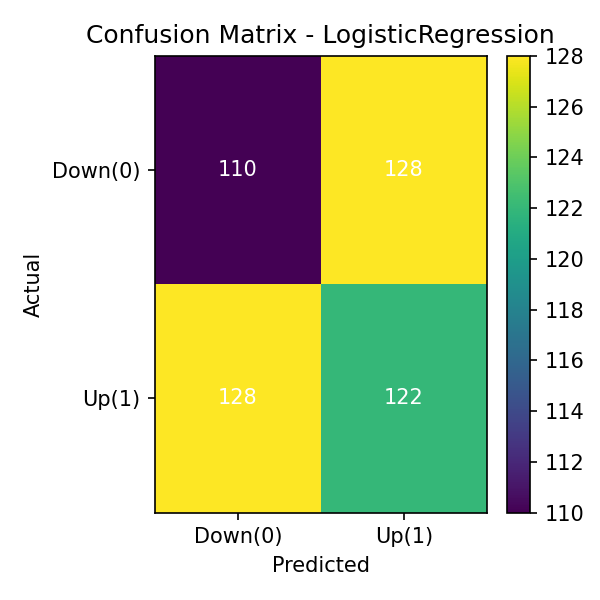

--- RandomForest ---
Accuracy: 0.5
Precision: 0.5138888888888888
Recall: 0.444
F1: 0.47639484978540775
ROC AUC: 0.504
Confusion matrix:
 [[133 105]
 [139 111]]
              precision    recall  f1-score   support

           0       0.49      0.56      0.52       238
           1       0.51      0.44      0.48       250

    accuracy                           0.50       488
   macro avg       0.50      0.50      0.50       488
weighted avg       0.50      0.50      0.50       488



📊 Displaying: ml_results_plots/confmat_RandomForest.png


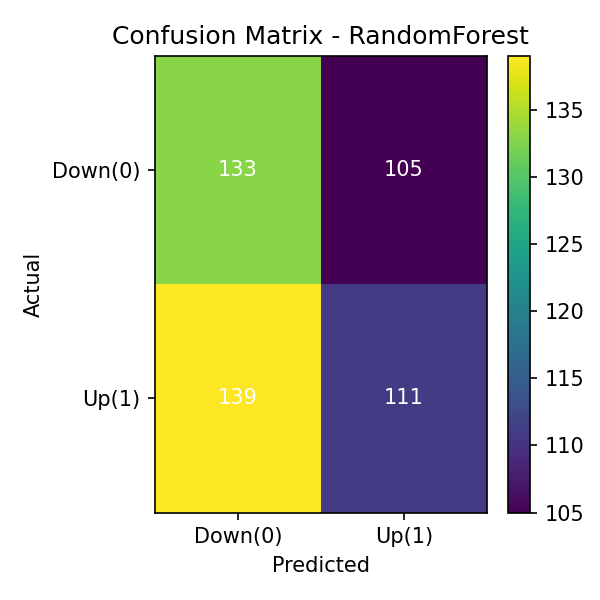

--- XGBoost ---
Accuracy: 0.48975409836065575
Precision: 0.502262443438914
Recall: 0.444
F1: 0.4713375796178344
ROC AUC: 0.48302521008403365
Confusion matrix:
 [[128 110]
 [139 111]]
              precision    recall  f1-score   support

           0       0.48      0.54      0.51       238
           1       0.50      0.44      0.47       250

    accuracy                           0.49       488
   macro avg       0.49      0.49      0.49       488
weighted avg       0.49      0.49      0.49       488



📊 Displaying: ml_results_plots/confmat_XGBoost.png


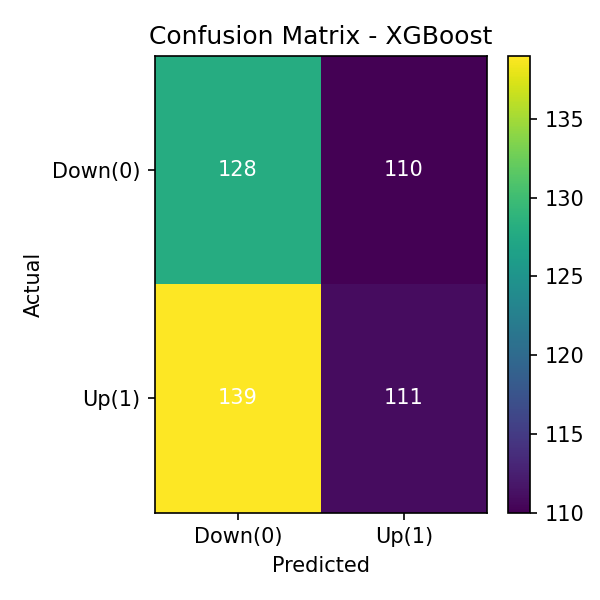

--- SVM_RBF ---
Accuracy: 0.4733606557377049
Precision: 0.4867924528301887
Recall: 0.516
F1: 0.5009708737864078
ROC AUC: 0.48069747899159665
Confusion matrix:
 [[102 136]
 [121 129]]
              precision    recall  f1-score   support

           0       0.46      0.43      0.44       238
           1       0.49      0.52      0.50       250

    accuracy                           0.47       488
   macro avg       0.47      0.47      0.47       488
weighted avg       0.47      0.47      0.47       488



📊 Displaying: ml_results_plots/confmat_SVM_RBF.png


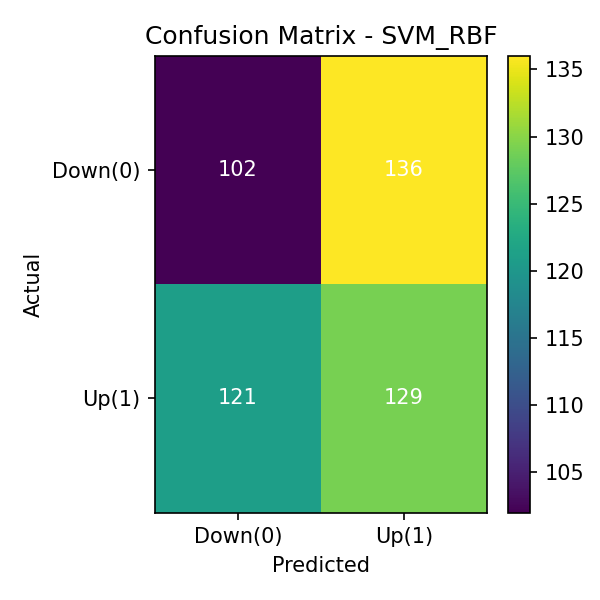

--- LightGBM ---
Accuracy: 0.5081967213114754
Precision: 0.5240384615384616
Recall: 0.436
F1: 0.4759825327510917
ROC AUC: 0.48544537815126054
Confusion matrix:
 [[139  99]
 [141 109]]
              precision    recall  f1-score   support

           0       0.50      0.58      0.54       238
           1       0.52      0.44      0.48       250

    accuracy                           0.51       488
   macro avg       0.51      0.51      0.51       488
weighted avg       0.51      0.51      0.51       488



📊 Displaying: ml_results_plots/confmat_LightGBM.png


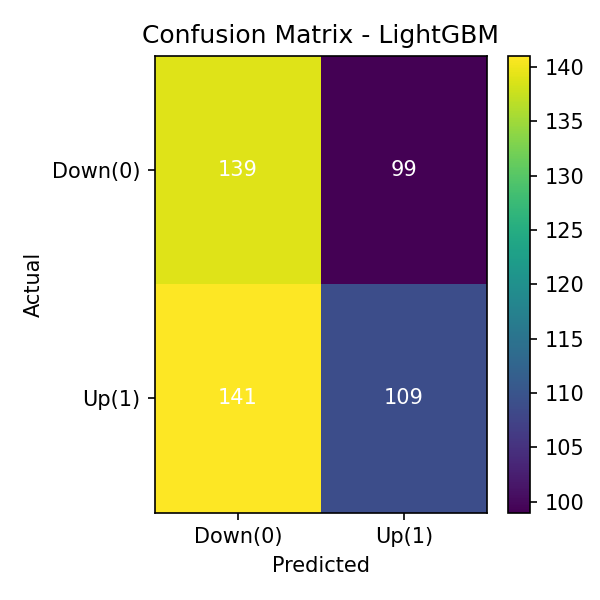


📈 Displaying: ml_results_plots/roc_all_models.png


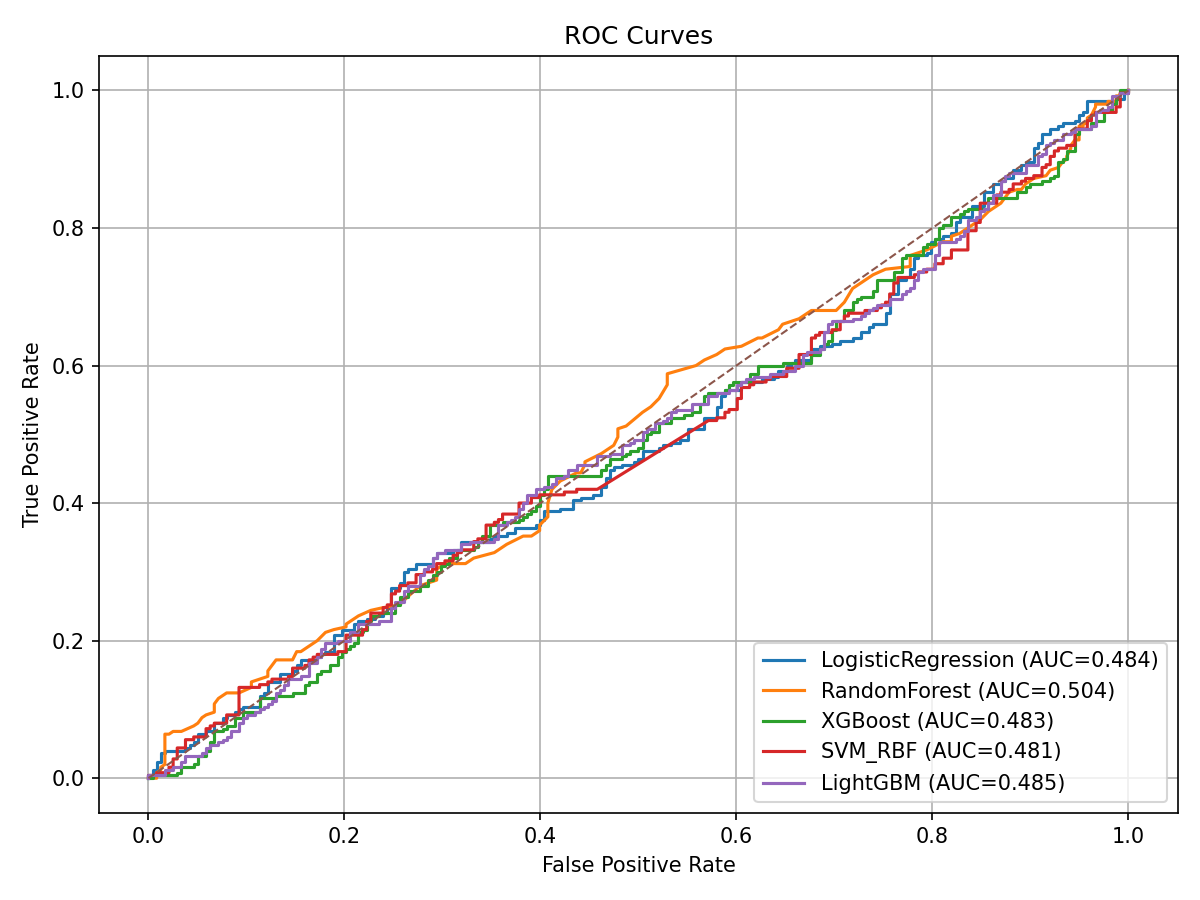


🧠 Displaying: ml_results_plots/featimp_RandomForest.png


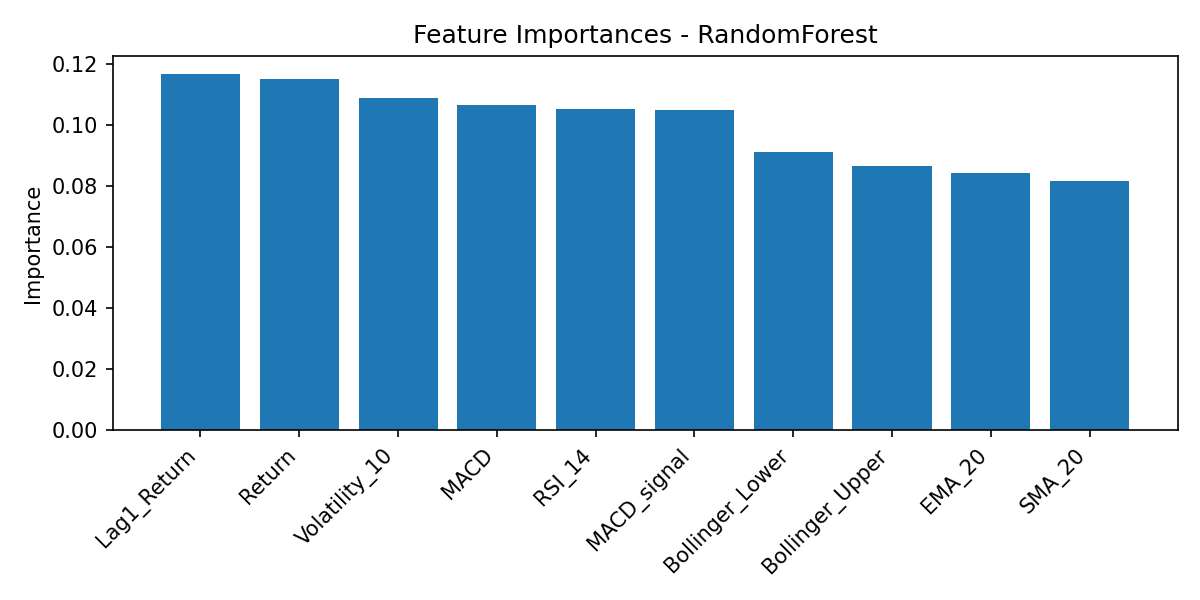


🧠 Displaying: ml_results_plots/featimp_XGBoost.png


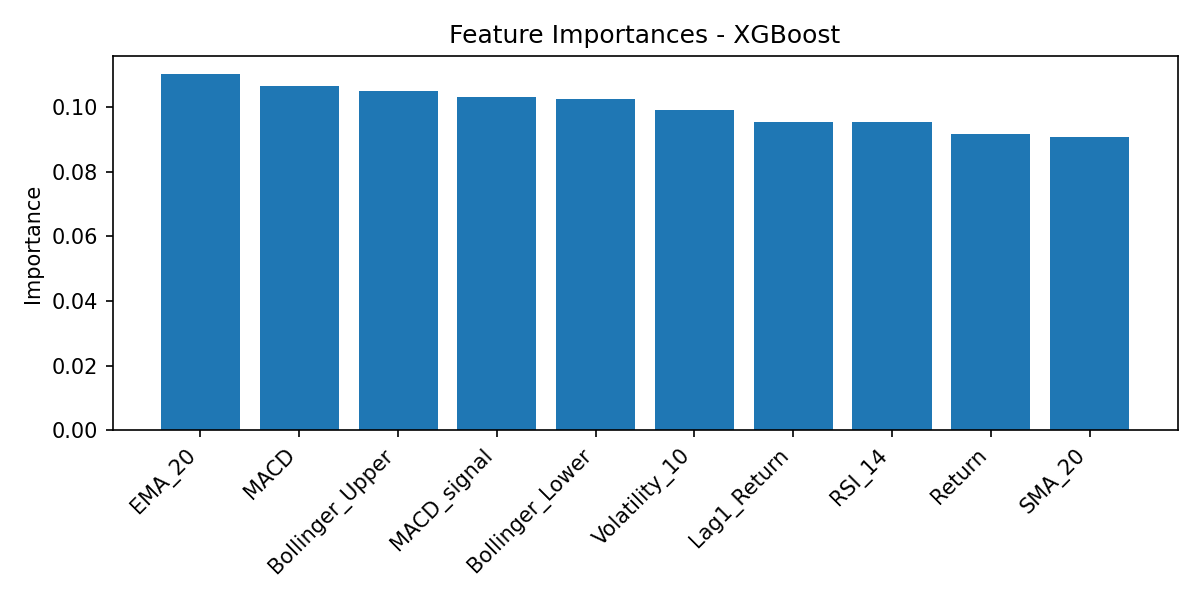


🧠 Displaying: ml_results_plots/featimp_LightGBM.png


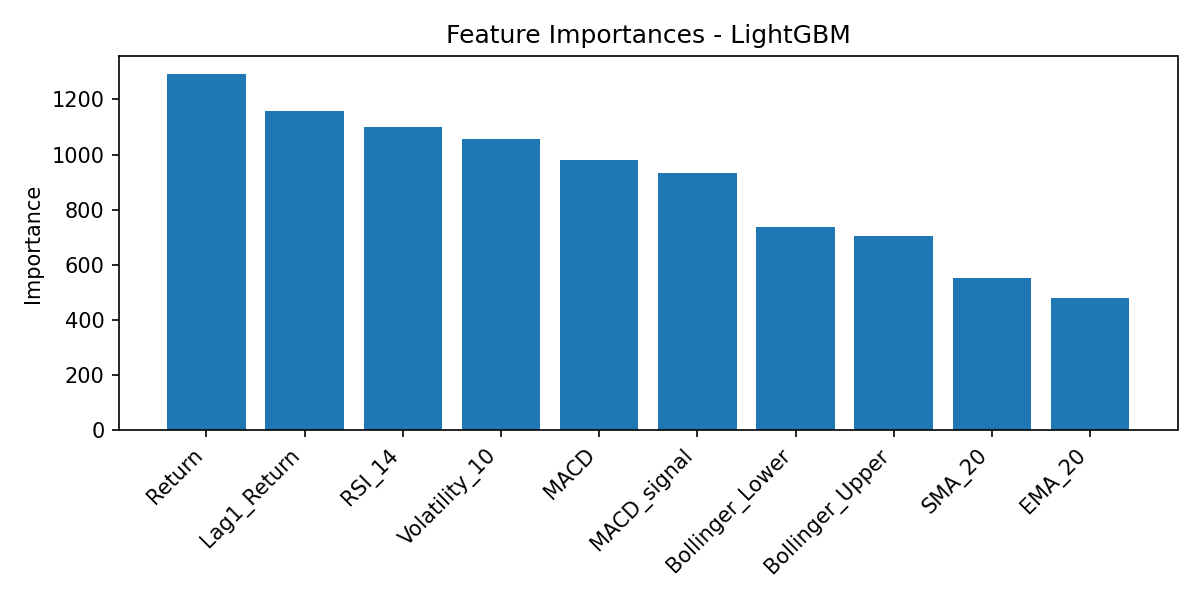


🧩 Displaying: ml_results_plots/featimp_LogisticRegression.png


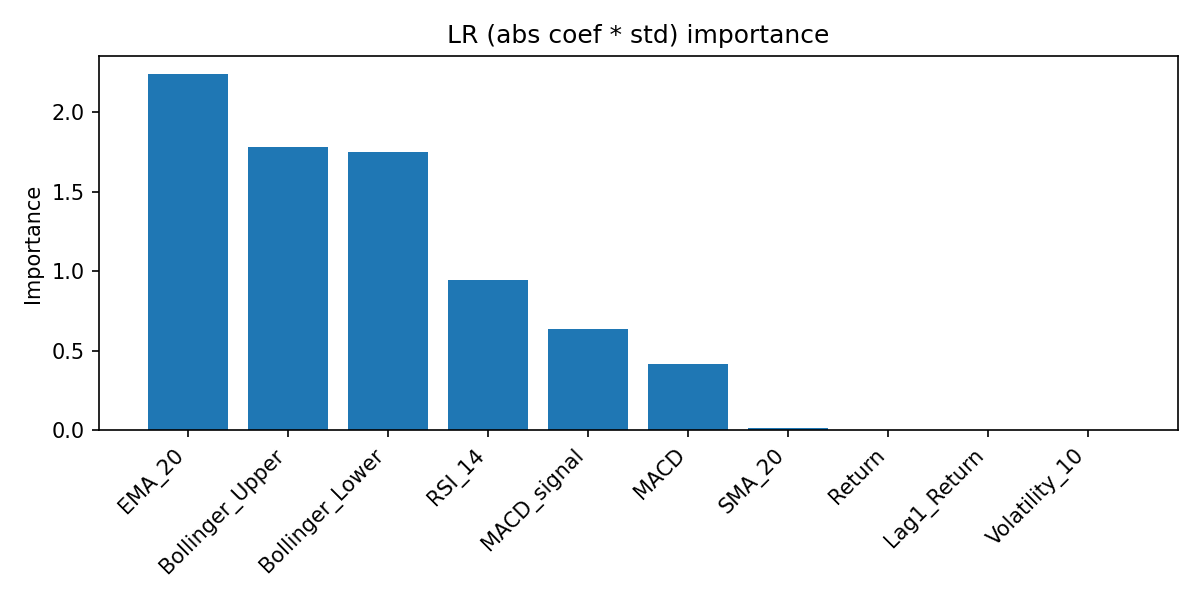

In [34]:
# ML training and evaluation with visualizations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, auc, classification_report
)
from sklearn.inspection import permutation_importance

# ---------- CONFIG ----------
CSV_PATH = "equities_with_features.csv"
FEATURES = [
    'SMA_20', 'EMA_20', 'RSI_14', 'MACD', 'MACD_signal',
    'Bollinger_Upper', 'Bollinger_Lower', 'Return', 'Lag1_Return', 'Volatility_10'
]
TEST_RATIO = 0.20
RANDOM_STATE = 42
OUTPUT_DIR = "ml_results_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------- 1) Load & prepare ----------
df = pd.read_csv(CSV_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Symbol', 'Date']).reset_index(drop=True)

# create next-day direction target
df['Next_Close'] = df.groupby('Symbol')['Close'].shift(-1)
df['Direction'] = (df['Next_Close'] > df['Close']).astype(int)
df = df.dropna(subset=FEATURES + ['Direction']).reset_index(drop=True)

# time-based per-symbol split
train_parts, test_parts = [], []
for symbol, g in df.groupby('Symbol', sort=True):
    g = g.sort_values('Date')
    n = len(g)
    if n < 10:
        train_parts.append(g)
        continue
    split_idx = int(np.floor((1 - TEST_RATIO) * n))
    if split_idx < 1:
        split_idx = 1
    train_parts.append(g.iloc[:split_idx])
    test_parts.append(g.iloc[split_idx:])

train_df = pd.concat(train_parts).reset_index(drop=True)
test_df  = pd.concat(test_parts).reset_index(drop=True)

X_train = train_df[FEATURES].copy()
y_train = train_df['Direction'].astype(int).copy()
X_test  = test_df[FEATURES].copy()
y_test  = test_df['Direction'].astype(int).copy()

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train positive rate:", y_train.mean(), "Test positive rate:", y_test.mean())

# ---------- 2) Define & train models ----------
models = {}

# Logistic Regression (scaled)
models['LogisticRegression'] = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
])
models['LogisticRegression'].fit(X_train, y_train)

# Random Forest
models['RandomForest'] = RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
models['RandomForest'].fit(X_train, y_train)

# XGBoost
# compute scale_pos_weight if needed
num_pos = (y_train == 1).sum()
num_neg = (y_train == 0).sum()
scale_pos_weight = (num_neg / num_pos) if num_pos > 0 else 1.0

models['XGBoost'] = XGBClassifier(
    n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE,
    use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight, n_jobs=-1
)
models['XGBoost'].fit(X_train, y_train)

# SVM (RBF) - scaled and probability=True
models['SVM_RBF'] = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE))
])
models['SVM_RBF'].fit(X_train, y_train)

# LightGBM
models['LightGBM'] = LGBMClassifier(
    n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE,
    class_weight='balanced', n_jobs=-1
)
models['LightGBM'].fit(X_train, y_train)

# Save models
for name, model in models.items():
    joblib.dump(model, f"{OUTPUT_DIR}/model_{name}.pkl")

# ---------- 3) Evaluation and plotting helpers ----------
def print_metrics(name, y_true, y_pred, y_proba=None):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall:", recall_score(y_true, y_pred, zero_division=0))
    print("F1:", f1_score(y_true, y_pred, zero_division=0))
    if y_proba is not None and len(np.unique(y_true)) > 1:
        print("ROC AUC:", roc_auc_score(y_true, y_proba))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred, zero_division=0))
    print()

# plot confusion matrix heatmap (matplotlib only)
def plot_confusion_matrix(cm, labels, title, outpath):
    fig, ax = plt.subplots(figsize=(4,4))
    im = ax.imshow(cm, interpolation='nearest', aspect='auto')
    plt.colorbar(im, ax=ax)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

    # annotate counts
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(int(cm[i, j]), 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    fig.savefig(outpath, dpi=150)
    plt.close(fig)

# plot ROC curves for all models
def plot_rocs(model_results, outpath):
    plt.figure(figsize=(8,6))
    for name, res in model_results.items():
        if res['y_proba'] is None:
            continue
        fpr, tpr, _ = roc_curve(res['y_true'], res['y_proba'])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
    plt.plot([0,1],[0,1],'--', linewidth=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(outpath, dpi=150)
    plt.close()

# feature importance plotting (bar chart)
def plot_feature_importances(feature_names, importances, title, outpath, top_n=10):
    # sort descending
    idx = np.argsort(importances)[::-1][:top_n]
    sorted_feats = [feature_names[i] for i in idx]
    sorted_imps = importances[idx]

    fig, ax = plt.subplots(figsize=(8,4))
    ax.bar(range(len(sorted_imps)), sorted_imps)
    ax.set_xticks(range(len(sorted_imps)))
    ax.set_xticklabels(sorted_feats, rotation=45, ha='right')
    ax.set_ylabel('Importance')
    ax.set_title(title)
    plt.tight_layout()
    fig.savefig(outpath, dpi=150)
    plt.close(fig)

# ---------- 4) Evaluate each model, save plots ----------
model_results = {}
for name, model in models.items():
    # probabilities if supported
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
    except Exception:
        y_proba = None

    y_pred = model.predict(X_test)
    print_metrics(name, y_test, y_pred, y_proba)

    cm = confusion_matrix(y_test, y_pred)
    plot_confusion_matrix(cm, labels=['Down(0)','Up(1)'],
                          title=f"Confusion Matrix - {name}",
                          outpath=f"{OUTPUT_DIR}/confmat_{name}.png")

    model_results[name] = {'y_true': y_test.values, 'y_pred': y_pred, 'y_proba': y_proba}

# ROC plot (all models)
plot_rocs(model_results, f"{OUTPUT_DIR}/roc_all_models.png")

# ---------- 5) Feature importance ----------
# For tree models: RandomForest, XGBoost, LightGBM
tree_models = ['RandomForest', 'XGBoost', 'LightGBM']
for tm in tree_models:
    model = models.get(tm)
    if model is None:
        continue
    # get feature importances robustly:
    try:
        importances = model.feature_importances_
    except Exception:
        # if model is a Pipeline (not here) or attribute missing, use permutation importance
        perm = permutation_importance(model, X_test, y_test, n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
        importances = perm.importances_mean

    plot_feature_importances(FEATURES, importances,
                             title=f"Feature Importances - {tm}",
                             outpath=f"{OUTPUT_DIR}/featimp_{tm}.png",
                             top_n=len(FEATURES))

# Logistic Regression coefficients (as importance)
lr = models['LogisticRegression']
coef = lr.named_steps['clf'].coef_.ravel()
# For scaling effect: we can compute importance by coefficient * std(feature) (approx)
feat_std = X_train.std(axis=0).values
lr_importance = np.abs(coef * feat_std)
plot_feature_importances(FEATURES, lr_importance,
                         title="LR (abs coef * std) importance",
                         outpath=f"{OUTPUT_DIR}/featimp_LogisticRegression.png",
                         top_n=len(FEATURES))

print("Plots saved to folder:", OUTPUT_DIR)

# ---------- 4) Evaluate each model, save and show plots ----------
from IPython.display import Image, display
import time

model_results = {}
for name, model in models.items():
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
    except Exception:
        y_proba = None

    y_pred = model.predict(X_test)
    print_metrics(name, y_test, y_pred, y_proba)

    cm = confusion_matrix(y_test, y_pred)
    cm_path = f"{OUTPUT_DIR}/confmat_{name}.png"
    plot_confusion_matrix(
        cm, labels=['Down(0)', 'Up(1)'],
        title=f"Confusion Matrix - {name}",
        outpath=cm_path
    )

    # 🖼️ Display confusion matrix
    if os.path.exists(cm_path):
        print(f"\n📊 Displaying: {cm_path}")
        try:
            display(Image(filename=cm_path))
        except Exception:
            img = plt.imread(cm_path)
            plt.imshow(img)
            plt.axis("off")
            plt.show()
        time.sleep(0.5)

    model_results[name] = {'y_true': y_test.values, 'y_pred': y_pred, 'y_proba': y_proba}

# ROC Curves
roc_path = f"{OUTPUT_DIR}/roc_all_models.png"
plot_rocs(model_results, roc_path)
if os.path.exists(roc_path):
    print(f"\n📈 Displaying: {roc_path}")
    try:
        display(Image(filename=roc_path))
    except Exception:
        img = plt.imread(roc_path)
        plt.imshow(img)
        plt.axis("off")
        plt.show()
    time.sleep(0.5)

# ---------- 5) Feature importance (save + show) ----------
tree_models = ['RandomForest', 'XGBoost', 'LightGBM']
for tm in tree_models:
    model = models.get(tm)
    if model is None:
        continue
    try:
        importances = model.feature_importances_
    except Exception:
        perm = permutation_importance(model, X_test, y_test, n_repeats=20,
                                      random_state=RANDOM_STATE, n_jobs=-1)
        importances = perm.importances_mean

    imp_path = f"{OUTPUT_DIR}/featimp_{tm}.png"
    plot_feature_importances(
        FEATURES, importances,
        title=f"Feature Importances - {tm}",
        outpath=imp_path,
        top_n=len(FEATURES)
    )

    # 🖼️ Display feature importance
    if os.path.exists(imp_path):
        print(f"\n🧠 Displaying: {imp_path}")
        try:
            display(Image(filename=imp_path))
        except Exception:
            img = plt.imread(imp_path)
            plt.imshow(img)
            plt.axis("off")
            plt.show()
        time.sleep(0.5)

# Logistic Regression importance
lr = models['LogisticRegression']
coef = lr.named_steps['clf'].coef_.ravel()
feat_std = X_train.std(axis=0).values
lr_importance = np.abs(coef * feat_std)
lr_path = f"{OUTPUT_DIR}/featimp_LogisticRegression.png"
plot_feature_importances(
    FEATURES, lr_importance,
    title="LR (abs coef * std) importance",
    outpath=lr_path,
    top_n=len(FEATURES)
)

# 🖼️ Display LR importance
if os.path.exists(lr_path):
    print(f"\n🧩 Displaying: {lr_path}")
    try:
        display(Image(filename=lr_path))
    except Exception:
        img = plt.imread(lr_path)
        plt.imshow(img)
        plt.axis("off")
        plt.show()
    time.sleep(0.5)




/tmp/ipython-input-237517169.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_df['MeanImportance'], y=feature_df.index, palette='viridis')


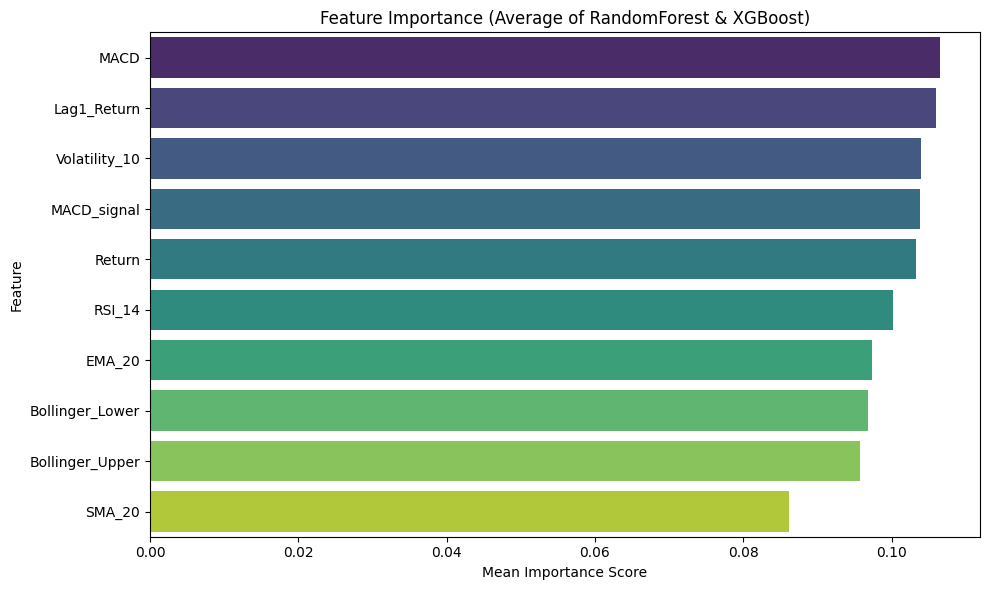


🔍 Top 5 Most Predictive Features:
               RandomForest   XGBoost  MeanImportance
Feature                                              
MACD               0.106615  0.106571        0.106593
Lag1_Return        0.116659  0.095349        0.106004
Volatility_10      0.108742  0.099246        0.103994
MACD_signal        0.104739  0.103003        0.103871
Return             0.114825  0.091763        0.103294

🧠 Interpretation:
- High importance for RSI / MACD → short-term momentum drives signal.
- High importance for Volatility or Bollinger Bands → market uncertainty and overbought/oversold conditions matter.
- Lag1_Return importance → short-term continuation or reversal effects.



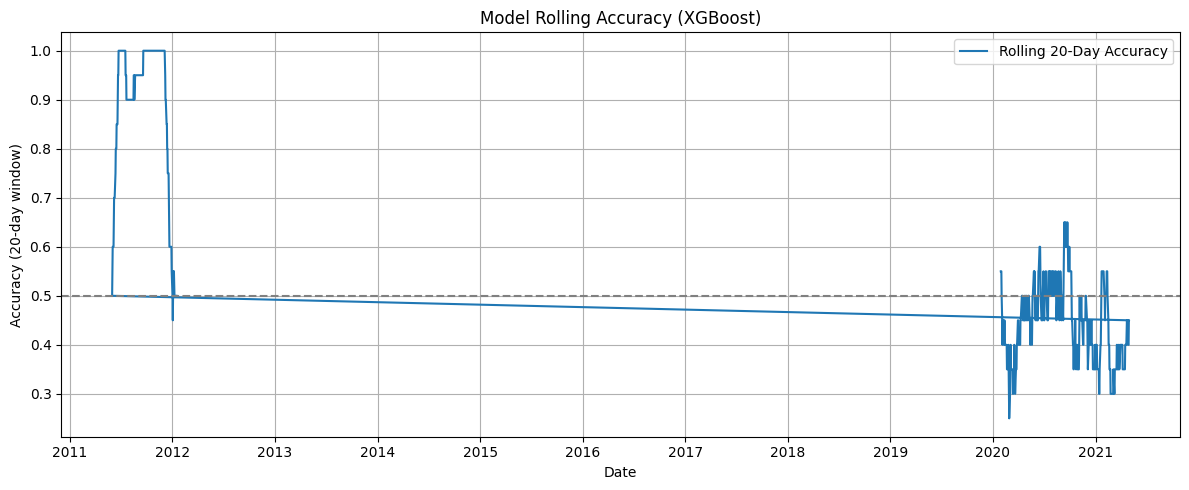

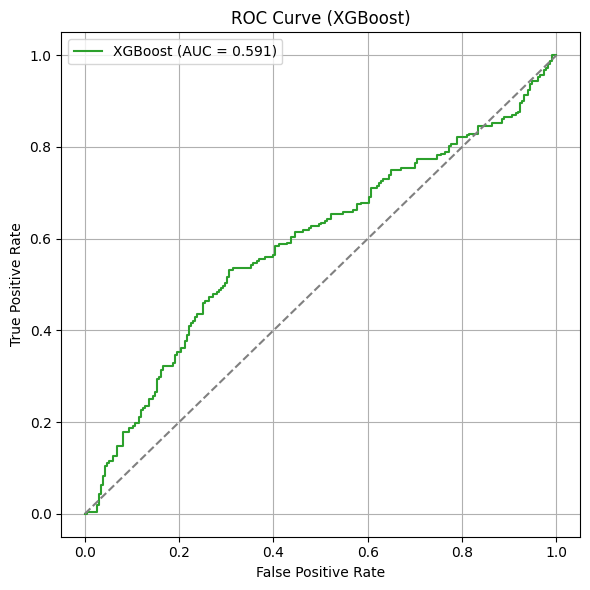

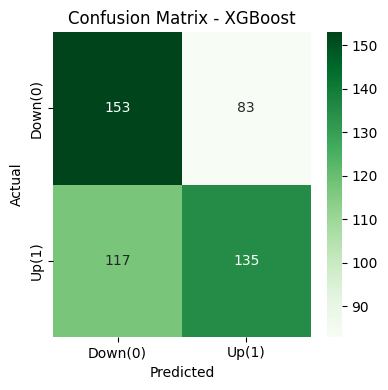

XGBoost Performance Summary:
Accuracy: 0.5901639344262295
F1 Score: 0.574468085106383
              precision    recall  f1-score   support

           0       0.57      0.65      0.60       236
           1       0.62      0.54      0.57       252

    accuracy                           0.59       488
   macro avg       0.59      0.59      0.59       488
weighted avg       0.59      0.59      0.59       488



In [35]:
# Evaluation and interpretation of model results with visualizations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, f1_score, classification_report
import joblib

# Load trained models (from previous script)
rf = joblib.load("ml_results_plots/model_RandomForest.pkl")
xgb = joblib.load("ml_results_plots/model_XGBoost.pkl")
lr = joblib.load("ml_results_plots/model_LogisticRegression.pkl")

# Load same dataset
df = pd.read_csv("equities_with_features.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Symbol', 'Date']).reset_index(drop=True)

# Features used in training
FEATURES = [
    'SMA_20', 'EMA_20', 'RSI_14', 'MACD', 'MACD_signal',
    'Bollinger_Upper', 'Bollinger_Lower', 'Return', 'Lag1_Return', 'Volatility_10'
]

# Define target (next-day direction)
df['Next_Close'] = df.groupby('Symbol')['Close'].shift(-1)
df['Direction'] = (df['Next_Close'] > df['Close']).astype(int)
df = df.dropna(subset=FEATURES + ['Direction']).reset_index(drop=True)

# Split (same as before)
split_idx = int(0.8 * len(df))
X_train, X_test = df[FEATURES].iloc[:split_idx], df[FEATURES].iloc[split_idx:]
y_train, y_test = df['Direction'].iloc[:split_idx], df['Direction'].iloc[split_idx:]
dates = df['Date'].iloc[split_idx:]  # for plotting time-based signals

# 1️⃣ ---- FEATURE IMPORTANCE ----
rf_importance = rf.feature_importances_
xgb_importance = xgb.feature_importances_

feature_df = pd.DataFrame({
    'Feature': FEATURES,
    'RandomForest': rf_importance,
    'XGBoost': xgb_importance
}).set_index('Feature')

feature_df['MeanImportance'] = feature_df.mean(axis=1)
feature_df = feature_df.sort_values('MeanImportance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feature_df['MeanImportance'], y=feature_df.index, palette='viridis')
plt.title('Feature Importance (Average of RandomForest & XGBoost)')
plt.xlabel('Mean Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance_combined.png', dpi=150)
plt.show()

print("\n🔍 Top 5 Most Predictive Features:")
print(feature_df.head(5))

# Interpretation tips
print("""
🧠 Interpretation:
- High importance for RSI / MACD → short-term momentum drives signal.
- High importance for Volatility or Bollinger Bands → market uncertainty and overbought/oversold conditions matter.
- Lag1_Return importance → short-term continuation or reversal effects.
""")

# 2️⃣ ---- ACTUAL vs PREDICTED SIGNAL ----
# We'll use XGBoost for this visualization
y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    'Date': dates.values,
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Prob_Up': y_proba
}).reset_index(drop=True)

# Rolling window to visualize model hit rate
results['RollingAcc'] = results['Actual'].eq(results['Predicted']).rolling(window=20).mean()

plt.figure(figsize=(12,5))
plt.plot(results['Date'], results['RollingAcc'], label='Rolling 20-Day Accuracy', color='tab:blue')
plt.axhline(0.5, color='gray', linestyle='--')
plt.title('Model Rolling Accuracy (XGBoost)')
plt.xlabel('Date')
plt.ylabel('Accuracy (20-day window)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('rolling_accuracy.png', dpi=150)
plt.show()

# 3️⃣ ---- ROC Curve + Confusion Matrix ----
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.3f})', color='tab:green')
plt.plot([0,1],[0,1],'--',color='gray')
plt.title('ROC Curve (XGBoost)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_xgboost.png', dpi=150)
plt.show()

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Down(0)','Up(1)'], yticklabels=['Down(0)','Up(1)'])
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('conf_matrix_xgb.png', dpi=150)
plt.show()

# Print model summary
print("XGBoost Performance Summary:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
